# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 01 — Exploratory Data Analysis (EDA)
**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle (Paul Mooney)
**Classes:** NORMAL vs PNEUMONIA
**Goal:** Understand dataset structure, class distribution, and image properties

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [4]:
BASE_DIR = '../data/chest_xray/chest_xray'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
CLASSES   = ['NORMAL', 'PNEUMONIA']

print(f'Train exists: {os.path.exists(TRAIN_DIR)}')
print(f'Val exists:   {os.path.exists(VAL_DIR)}')
print(f'Test exists:  {os.path.exists(TEST_DIR)}')

Train exists: True
Val exists:   True
Test exists:  True


In [5]:
def count_images(directory):
    counts = {}
    for cls in CLASSES:
        path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(path)) if os.path.exists(path) else 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

summary = pd.DataFrame({
    'Split':     ['Train', 'Validation', 'Test'],
    'NORMAL':    [train_counts['NORMAL'],    val_counts['NORMAL'],    test_counts['NORMAL']],
    'PNEUMONIA': [train_counts['PNEUMONIA'], val_counts['PNEUMONIA'], test_counts['PNEUMONIA']],
})
summary['Total'] = summary['NORMAL'] + summary['PNEUMONIA']

print('📊 Dataset Summary:')
print(summary.to_string(index=False))
print(f"\n🔢 Grand Total: {summary['Total'].sum()} images")

📊 Dataset Summary:
     Split  NORMAL  PNEUMONIA  Total
     Train    1342       3876   5218
Validation       9          9     18
      Test     234        390    624

🔢 Grand Total: 5860 images


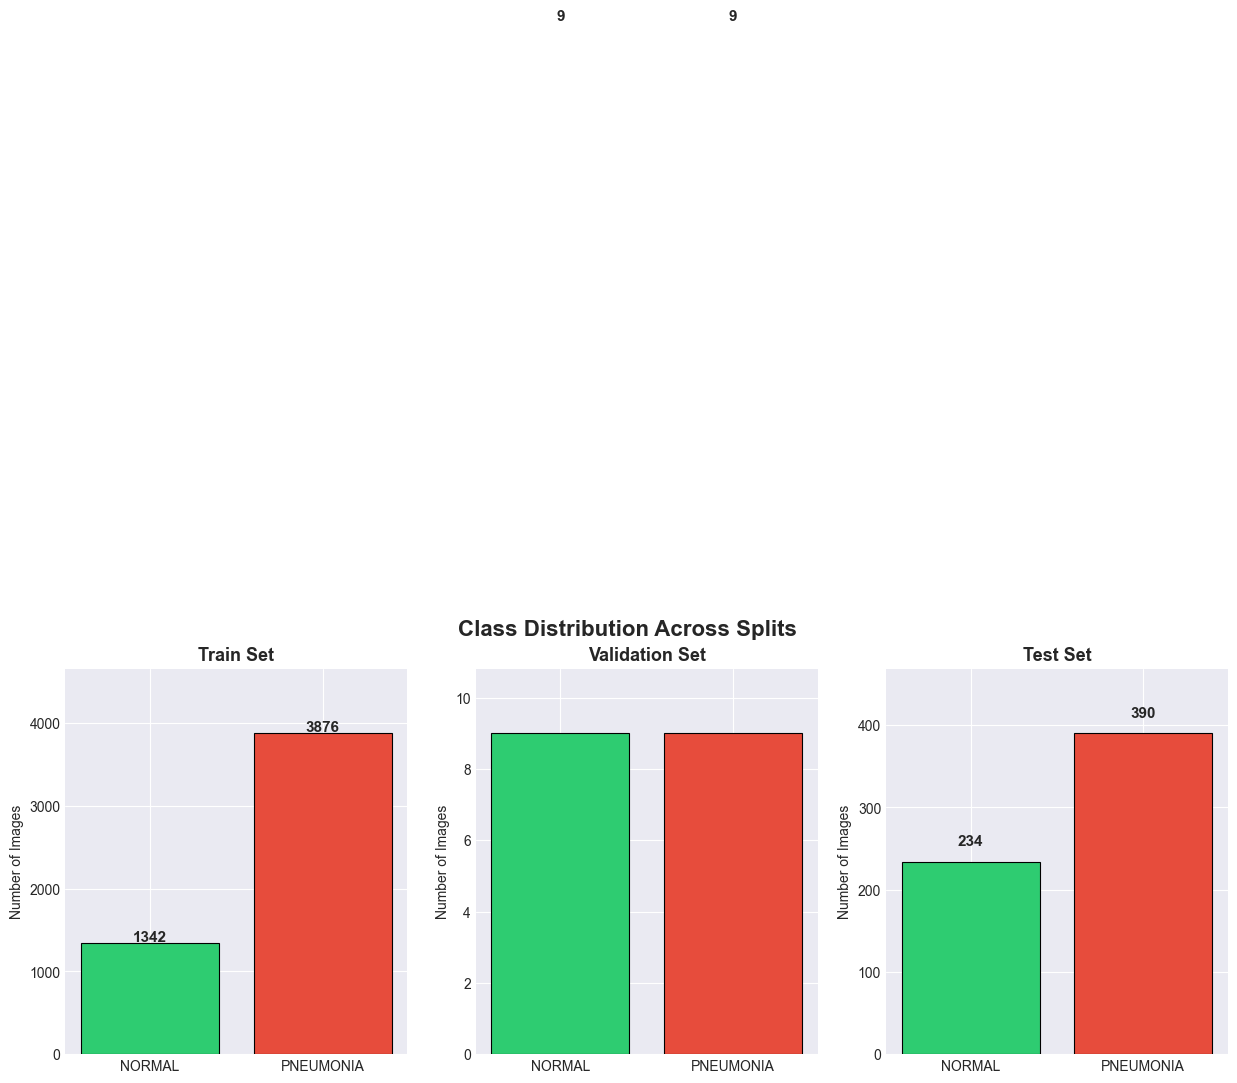

✅ Saved: outputs/class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Class Distribution Across Splits', fontsize=16, fontweight='bold')

splits = [
    ('Train',      train_counts),
    ('Validation', val_counts),
    ('Test',       test_counts),
]
colors = ['#2ecc71', '#e74c3c']

for ax, (title, counts) in zip(axes, splits):
    bars = ax.bar(CLASSES, [counts[c] for c in CLASSES],
                  color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{title} Set', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_ylim(0, max(counts.values()) * 1.2)
    for bar, val in zip(bars, [counts[c] for c in CLASSES]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                str(val), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/class_distribution.png')

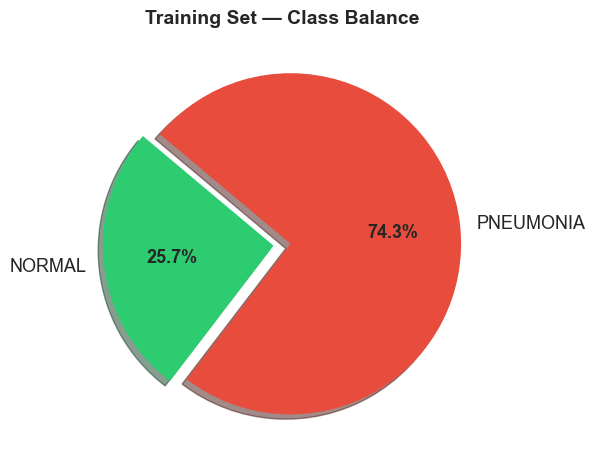

✅ Saved: outputs/class_balance_pie.png


In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
sizes   = [train_counts['NORMAL'], train_counts['PNEUMONIA']]
labels  = ['NORMAL', 'PNEUMONIA']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], explode=explode,
    startangle=140, shadow=True,
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Training Set — Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/class_balance_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/class_balance_pie.png')

In [9]:
def get_sample_images(directory, cls, n=5):
    path  = os.path.join(directory, cls)
    files = [f for f in os.listdir(path) 
             if f.lower().endswith(('.jpeg', '.jpg', '.png'))][:n]
    return [os.path.join(path, f) for f in files]

Width  — Min: 502, Max: 2538, Mean: 1442
Height — Min: 307, Max: 2066, Mean: 1086


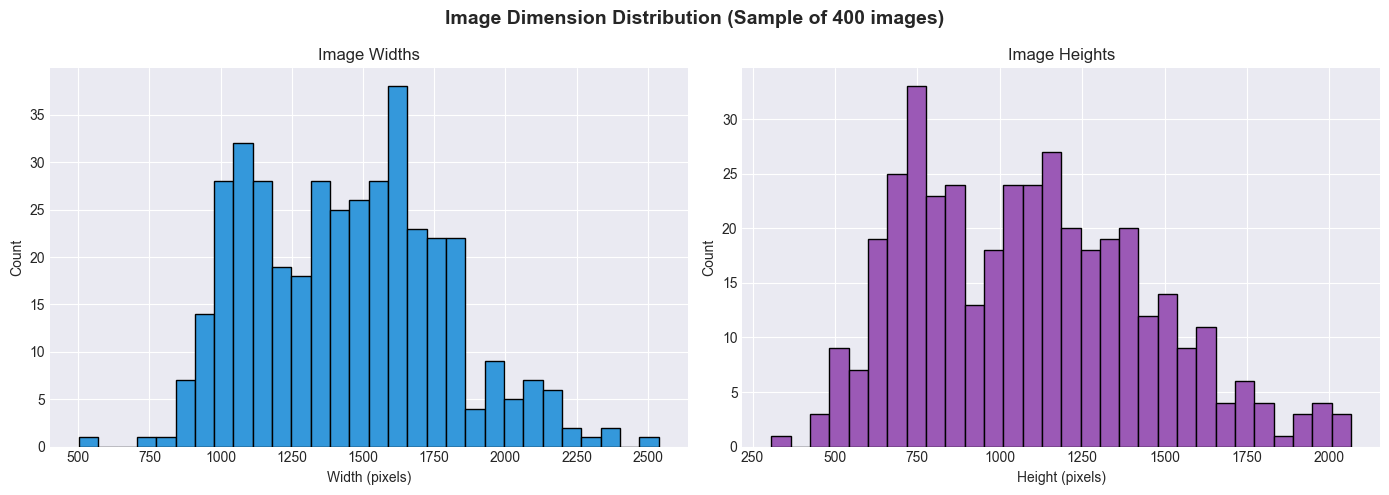

In [10]:
widths, heights = [], []

for cls in CLASSES:
    path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(path)[:200]:
        try:
            with Image.open(os.path.join(path, fname)) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            pass

print(f'Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}')
print(f'Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Image Dimension Distribution (Sample of 400 images)',
             fontsize=14, fontweight='bold')

axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=30, color='#9b59b6', edgecolor='black')
axes[1].set_title('Image Heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

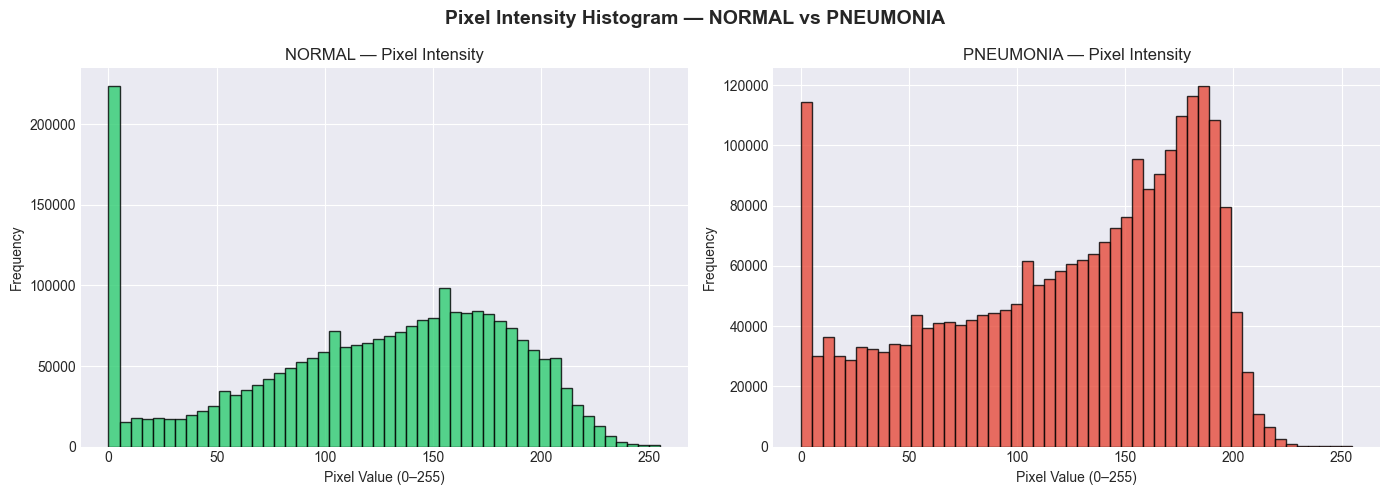

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Histogram — NORMAL vs PNEUMONIA',
             fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASSES):
    path = os.path.join(TRAIN_DIR, cls)
    all_pixels = []
    for fname in os.listdir(path)[:50]:
        try:
            img = Image.open(os.path.join(path, fname)).convert('L').resize((224, 224))
            all_pixels.extend(np.array(img).flatten().tolist())
        except:
            pass
    color = '#2ecc71' if cls == 'NORMAL' else '#e74c3c'
    axes[i].hist(all_pixels, bins=50, color=color, alpha=0.8, edgecolor='black')
    axes[i].set_title(f'{cls} — Pixel Intensity', fontsize=12)
    axes[i].set_xlabel('Pixel Value (0–255)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('=' * 55)
print('        EDA SUMMARY — CHEST X-RAY DATASET')
print('=' * 55)
print(f"Total Images        : {summary['Total'].sum()}")
print(f"Training Samples    : {summary.loc[0,'Total']}")
print(f"Validation Samples  : {summary.loc[1,'Total']}")
print(f"Test Samples        : {summary.loc[2,'Total']}")
print(f"Classes             : NORMAL, PNEUMONIA")
print(f"Class Imbalance     : Yes — PNEUMONIA >> NORMAL in train")
print(f"Image Format        : JPEG (Grayscale X-rays)")
print(f"Target Input Size   : 224 x 224 (for all models)")
print()
print('✅ Recommended : Use class_weight in training to handle imbalance')
print('✅ Next Step   : Notebook 02 — Custom CNN Model')

        EDA SUMMARY — CHEST X-RAY DATASET
Total Images        : 5860
Training Samples    : 5218
Validation Samples  : 18
Test Samples        : 624
Classes             : NORMAL, PNEUMONIA
Class Imbalance     : Yes — PNEUMONIA >> NORMAL in train
Image Format        : JPEG (Grayscale X-rays)
Target Input Size   : 224 x 224 (for all models)

✅ Recommended : Use class_weight in training to handle imbalance
✅ Next Step   : Notebook 02 — Custom CNN Model
